# 🧠 Digit Recognition using Neural Networks with PyTorch

---

## 📌 What are we building?

We will build a **Neural Network** that can recognize handwritten digits (0–9) from the famous **MNIST dataset** — 60,000 training images and 10,000 test images, each being a 28×28 grayscale image of a digit.

### 🗺️ Our Roadmap:
1. Import libraries
2. Load and explore the MNIST dataset
3. Visualize sample images
4. Build the Neural Network architecture
5. Train the model
6. Evaluate performance
7. Visualize predictions
8. Plot training curves

---

> **Why PyTorch?**  
> PyTorch is a flexible deep learning framework from Meta. It uses **dynamic computation graphs** (define-by-run), making it intuitive to debug and experiment with. It's the framework of choice in research and industry alike.

## 📦 Step 1: Import Libraries

We import the following:

| Library | Purpose |
|---|---|
| `torch` | Core PyTorch library for tensors and autograd |
| `torch.nn` | Building blocks for neural networks (layers, loss functions) |
| `torch.optim` | Optimizers like SGD, Adam |
| `torchvision.datasets` | Standard vision datasets including MNIST |
| `torchvision.transforms` | Data preprocessing / augmentation |
| `matplotlib` | Plotting and visualization |
| `numpy` | Numerical operations |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

print(f'PyTorch Version : {torch.__version__}')
print(f'Torchvision Version: {torchvision.__version__}')

# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n🖥️  Using device: {device}')

PyTorch Version : 2.11.0+cpu
Torchvision Version: 0.26.0+cpu

🖥️  Using device: cpu


## 📂 Step 2: Load the MNIST Dataset

### What is MNIST?
MNIST (**Modified National Institute of Standards and Technology**) is the "Hello World" of computer vision:
- **70,000 images** total (60,000 train + 10,000 test)
- Each image is **28 × 28 pixels**, grayscale
- 10 classes (digits **0 through 9**)

### Transforms — Why Normalize?
- `ToTensor()`: Converts PIL image (pixel values 0–255) → PyTorch tensor (values 0.0–1.0)
- `Normalize((0.1307,), (0.3081,))`: Subtracts mean `0.1307` and divides by std `0.3081` (precomputed for MNIST).

Normalization ensures all pixel values have **zero mean and unit variance**, which helps gradient descent converge faster and more stably.

### DataLoader
The `DataLoader` wraps a dataset and handles:
- **Batching**: Feeds data in mini-batches (we use batch_size=64)
- **Shuffling**: Randomizes order each epoch to reduce overfitting
- **Parallel loading**: Uses multiple CPU workers for speed

In [2]:
# ─── Hyperparameters ─────────────────────────────────────────────────────────
BATCH_SIZE   = 64      # Number of samples per mini-batch
LEARNING_RATE = 0.001  # Step size for optimizer
EPOCHS        = 10     # Number of full passes over the training set

# ─── Transforms ──────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL → Tensor, scale [0,255] → [0,1]
    transforms.Normalize((0.1307,), (0.3081,))    # Normalize with MNIST mean & std
])

# ─── Download & Load Datasets ─────────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# ─── DataLoaders ──────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples  : {len(train_dataset):,}')
print(f'Test samples      : {len(test_dataset):,}')
print(f'Training batches  : {len(train_loader)}')
print(f'Image shape       : {train_dataset[0][0].shape}  → (Channels, Height, Width)')

100.0%
100.0%
100.0%
100.0%


Training samples  : 60,000
Test samples      : 10,000
Training batches  : 938
Image shape       : torch.Size([1, 28, 28])  → (Channels, Height, Width)


## 🖼️ Step 3: Visualize Sample Images

Always visualize your data before building a model. This helps you:
- Confirm the dataset loaded correctly
- Understand what the model "sees"
- Spot any data quality issues early

Batch shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
Pixel range: [-0.424, 2.821]


C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\2704049462.py:18: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\2704049462.py:19: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
c:\Users\Sharmi\OneDrive\Documents\Machine Learning\pytorch-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


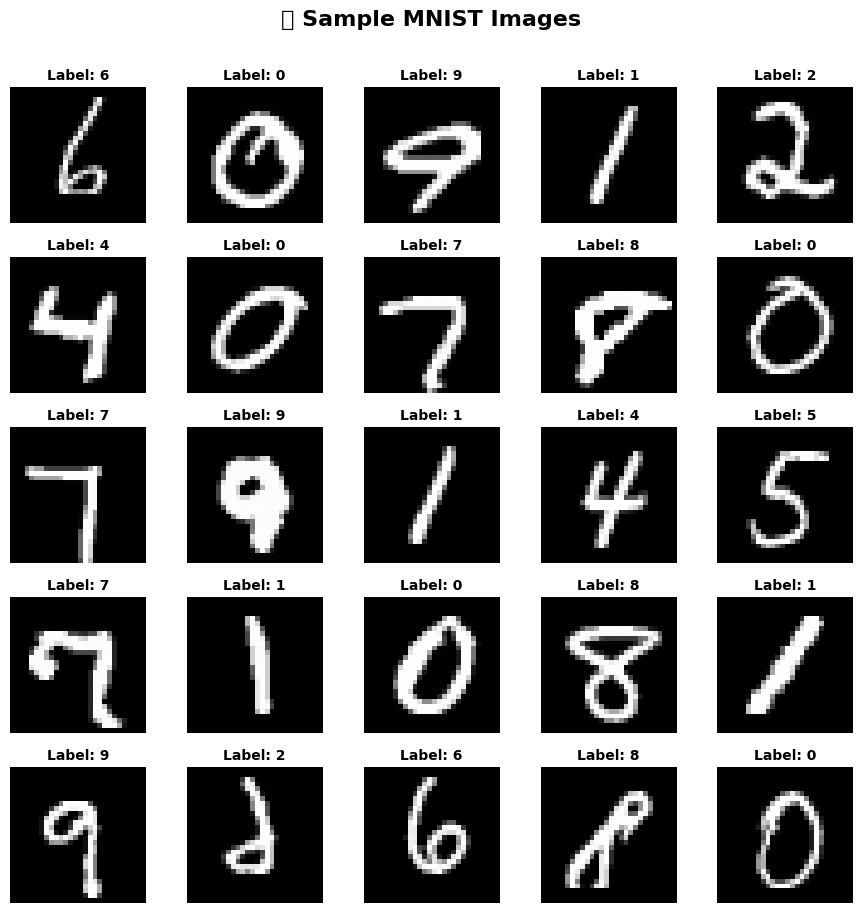

✅ Sample images visualized


In [3]:
# Grab one batch from the training loader
images, labels = next(iter(train_loader))

print(f'Batch shape: {images.shape}')   # [64, 1, 28, 28]  → [batch, channels, H, W]
print(f'Labels shape: {labels.shape}')  # [64]
print(f'Pixel range: [{images.min():.3f}, {images.max():.3f}]')   # After normalization

# ─── Plot 25 sample images ────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 5, figsize=(9, 9))
fig.suptitle('📷 Sample MNIST Images', fontsize=16, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()      # Remove channel dim: [1,28,28] → [28,28]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Sample images visualized')

## 🏗️ Step 4: Build the Neural Network

### Architecture: Fully Connected (MLP — Multi-Layer Perceptron)

```
Input Layer   →  784 neurons  (28×28 pixels flattened)
     ↓
Hidden Layer 1 → 512 neurons  + ReLU + Dropout(0.2)
     ↓
Hidden Layer 2 → 256 neurons  + ReLU + Dropout(0.2)
     ↓
Hidden Layer 3 → 128 neurons  + ReLU + Dropout(0.2)
     ↓
Output Layer  →  10 neurons   (one per digit class)
```

### Key Concepts:

| Concept | Explanation |
|---|---|
| **`nn.Linear(in, out)`** | Fully connected layer: computes `y = Wx + b` |
| **ReLU Activation** | `f(x) = max(0, x)` — adds non-linearity so the network can learn complex patterns |
| **Dropout** | Randomly sets a fraction of neurons to 0 during training → prevents overfitting |
| **`view(-1, 784)`** | Flattens the 2D image `[28×28]` into a 1D vector of 784 values |
| **`forward(x)`** | Defines the forward pass — how data flows through the network |

### Why 10 output neurons?
We have 10 classes (0–9). The model outputs 10 raw scores (**logits**). The class with the highest score is the prediction. During training, `CrossEntropyLoss` internally applies **Softmax** to turn logits into probabilities.

In [4]:
class DigitRecognizer(nn.Module):
    """
    A 3-hidden-layer fully connected neural network for MNIST digit classification.
    
    Architecture:
        Input  → FC(784→512) → ReLU → Dropout
               → FC(512→256) → ReLU → Dropout
               → FC(256→128) → ReLU → Dropout
               → FC(128→10)  → [logits]
    """
    def __init__(self, dropout_rate=0.2):
        super(DigitRecognizer, self).__init__()
        
        # ── Fully Connected Layers ──────────────────────────────────────────────
        # Layer 1: 784 → 512
        self.fc1 = nn.Linear(28 * 28, 512)
        
        # Layer 2: 512 → 256
        self.fc2 = nn.Linear(512, 256)
        
        # Layer 3: 256 → 128
        self.fc3 = nn.Linear(256, 128)
        
        # Output Layer: 128 → 10 (one score per digit class)
        self.fc4 = nn.Linear(128, 10)
        
        # ── Regularization ──────────────────────────────────────────────────────
        # Dropout randomly zeros neurons with probability `dropout_rate` during training
        # This forces the network not to rely on any single neuron → reduces overfitting
        self.dropout = nn.Dropout(dropout_rate)
        
        # ── Weight Initialization ───────────────────────────────────────────────
        # He (Kaiming) initialization is best suited for ReLU activations
        self._initialize_weights()
    
    def _initialize_weights(self):
        """He initialization for better gradient flow with ReLU."""
        for layer in [self.fc1, self.fc2, self.fc3, self.fc4]:
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        """
        Forward pass: defines how input data flows through the network.
        
        Args:
            x: input tensor of shape [batch_size, 1, 28, 28]
        Returns:
            logits: raw scores of shape [batch_size, 10]
        """
        # Step 1: Flatten the image from [B, 1, 28, 28] → [B, 784]
        # -1 means "infer this dimension automatically" (it becomes batch_size)
        x = x.view(-1, 28 * 28)
        
        # Step 2: Layer 1 → ReLU → Dropout
        x = self.dropout(F.relu(self.fc1(x)))
        
        # Step 3: Layer 2 → ReLU → Dropout
        x = self.dropout(F.relu(self.fc2(x)))
        
        # Step 4: Layer 3 → ReLU → Dropout
        x = self.dropout(F.relu(self.fc3(x)))
        
        # Step 5: Output layer (NO activation — CrossEntropyLoss handles softmax internally)
        x = self.fc4(x)
        
        return x   # Returns raw logits (unnormalized scores)


# ─── Instantiate model and move to device ─────────────────────────────────────
model = DigitRecognizer(dropout_rate=0.2).to(device)
print(model)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n📊 Total trainable parameters: {total_params:,}')

DigitRecognizer(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

📊 Total trainable parameters: 567,434


## ⚙️ Step 5: Define Loss Function & Optimizer

### Loss Function — CrossEntropyLoss
For multi-class classification, we use **Cross-Entropy Loss**:

$$\mathcal{L} = -\sum_{c=1}^{10} y_c \cdot \log(\hat{p}_c)$$

where `y_c = 1` for the true class and 0 otherwise.

In PyTorch, `nn.CrossEntropyLoss()` combines **LogSoftmax + NLLLoss** in one step — so **do not** apply softmax manually before the loss.

### Optimizer — Adam
**Adam** (Adaptive Moment Estimation) is the most popular optimizer because it:
- Adapts the learning rate **per parameter** using the history of gradients
- Combines the benefits of **momentum** (RMSprop) and **squared gradients** (AdaGrad)
- Works well out-of-the-box with `lr=0.001`

### Learning Rate Scheduler
**StepLR** reduces the learning rate by a factor (`gamma`) every N epochs. This lets the model take **larger steps early** (exploration) and **smaller steps later** (fine-tuning).

In [5]:
# ─── Loss Function ────────────────────────────────────────────────────────────
# CrossEntropyLoss = LogSoftmax + Negative Log Likelihood Loss
# Works directly on raw logits (no need for softmax in the model output)
criterion = nn.CrossEntropyLoss()

# ─── Optimizer ────────────────────────────────────────────────────────────────
# Adam optimizer with weight_decay (L2 regularization) to prevent overfitting
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# ─── Learning Rate Scheduler ──────────────────────────────────────────────────
# Reduce LR by 50% (gamma=0.5) every 3 epochs
# e.g., epoch 1-3: lr=0.001 → epoch 4-6: lr=0.0005 → ...
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print('✅ Loss function : CrossEntropyLoss')
print('✅ Optimizer     : Adam (lr=0.001, weight_decay=1e-4)')
print('✅ LR Scheduler  : StepLR (step=3, gamma=0.5)')

✅ Loss function : CrossEntropyLoss
✅ Optimizer     : Adam (lr=0.001, weight_decay=1e-4)
✅ LR Scheduler  : StepLR (step=3, gamma=0.5)


## 🔄 Step 6: Training & Evaluation Functions

### The Training Loop (one epoch)

Each epoch follows these steps for every mini-batch:

```
1. Forward Pass  → compute predictions (logits)
2. Compute Loss  → compare predictions vs true labels
3. Backward Pass → compute gradients via autograd (backpropagation)
4. Update Weights → optimizer.step() applies gradients
5. Zero Gradients → optimizer.zero_grad() clears old gradients
```

### `model.train()` vs `model.eval()`
| Mode | Dropout | BatchNorm | Use When |
|---|---|---|---|
| `model.train()` | **Active** (drops neurons) | Uses batch stats | **Training** |
| `model.eval()` | **Disabled** (all neurons used) | Uses running stats | **Evaluation / Inference** |

### `torch.no_grad()`
During evaluation, we don't need to compute gradients. `torch.no_grad()` disables gradient tracking, **saving memory and computation**.

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Returns:
        avg_loss (float): average training loss over all batches
        accuracy (float): training accuracy in percent
    """
    model.train()   # ← Activate dropout and batch norm training behavior
    
    running_loss   = 0.0
    correct        = 0
    total          = 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        # 1. Move data to the target device (GPU if available)
        images, labels = images.to(device), labels.to(device)
        
        # 2. Zero gradients from the previous step
        #    Without this, gradients accumulate across batches!
        optimizer.zero_grad()
        
        # 3. Forward pass: get raw predictions (logits)
        outputs = model(images)        # shape: [batch_size, 10]
        
        # 4. Compute loss between predictions and true labels
        loss = criterion(outputs, labels)
        
        # 5. Backward pass: compute gradients of loss w.r.t. all parameters
        loss.backward()
        
        # 6. Gradient clipping: prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 7. Update model parameters using computed gradients
        optimizer.step()
        
        # ── Track metrics ──────────────────────────────────────────────────────
        running_loss += loss.item() * images.size(0)      # Accumulate total loss
        
        # Get predicted class: argmax along dimension 1 (class dimension)
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)
    
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a dataset (no gradient computation).
    
    Returns:
        avg_loss (float): average loss
        accuracy (float): accuracy in percent
    """
    model.eval()    # ← Disable dropout; use running stats for batch norm
    
    running_loss   = 0.0
    correct        = 0
    total          = 0
    
    with torch.no_grad():   # ← No gradient tracking needed for evaluation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss    = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, dim=1)
            correct       += (predicted == labels).sum().item()
            total         += labels.size(0)
    
    avg_loss = running_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

print('✅ Training and evaluation functions defined!')

✅ Training and evaluation functions defined!


## 🚀 Step 7: Train the Model

We run training for `EPOCHS` epochs. After each epoch:
- Compute **training loss and accuracy**
- Compute **validation (test) loss and accuracy**
- Adjust learning rate via the scheduler
- Save the **best model weights** (based on test accuracy)

> **Tip:** Monitor both training and test metrics. If training accuracy is high but test accuracy is low → **overfitting**.

In [9]:
# ─── Training History Storage ─────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss':  [], 'test_acc':  []
}

best_accuracy = 0.0
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>10} | {'Test Loss':>10} | {'Test Acc':>10} | {'LR':>8}")
print('-' * 68)

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    
    # ── Train one epoch ────────────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # ── Evaluate on test set ───────────────────────────────────────────────────
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    # ── Step scheduler (adjusts learning rate) ─────────────────────────────────
    scheduler.step()
    
    # ── Save metrics ───────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # ── Save best model ────────────────────────────────────────────────────────
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(), 'best_digit_model.pth')
        flag = ' ⭐ BEST'
    else:
        flag = ''
    
    print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.2f}% | {test_loss:>10.4f} | {test_acc:>9.2f}%{flag}')

print(f'\n🏆 Best Test Accuracy: {best_accuracy:.2f}%')

 Epoch | Train Loss |  Train Acc |  Test Loss |   Test Acc |       LR
--------------------------------------------------------------------
     1 |     0.1034 |     97.06% |     0.0831 |     97.64% ⭐ BEST
     2 |     0.0640 |     98.10% |     0.0648 |     98.17% ⭐ BEST
     3 |     0.0538 |     98.38% |     0.0657 |     98.19% ⭐ BEST
     4 |     0.0501 |     98.44% |     0.0670 |     98.06%
     5 |     0.0319 |     99.03% |     0.0603 |     98.45% ⭐ BEST
     6 |     0.0269 |     99.17% |     0.0613 |     98.42%
     7 |     0.0248 |     99.22% |     0.0622 |     98.36%
     8 |     0.0182 |     99.43% |     0.0565 |     98.63% ⭐ BEST
     9 |     0.0147 |     99.56% |     0.0606 |     98.56%
    10 |     0.0147 |     99.53% |     0.0598 |     98.62%

🏆 Best Test Accuracy: 98.63%


## 📈 Step 8: Plot Training Curves

Training curves help diagnose model behavior:

| Pattern | Meaning |
|---|---|
| Both curves improve | Model is learning well ✅ |
| Train ↓, Test ↑ (diverging) | Overfitting — model memorizes train data ⚠️ |
| Both curves plateau early | Model may be underfitting — need more capacity |
| Very noisy curves | Learning rate may be too high |

C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\1616605431.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\1616605431.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
c:\Users\Sharmi\OneDrive\Documents\Machine Learning\pytorch-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


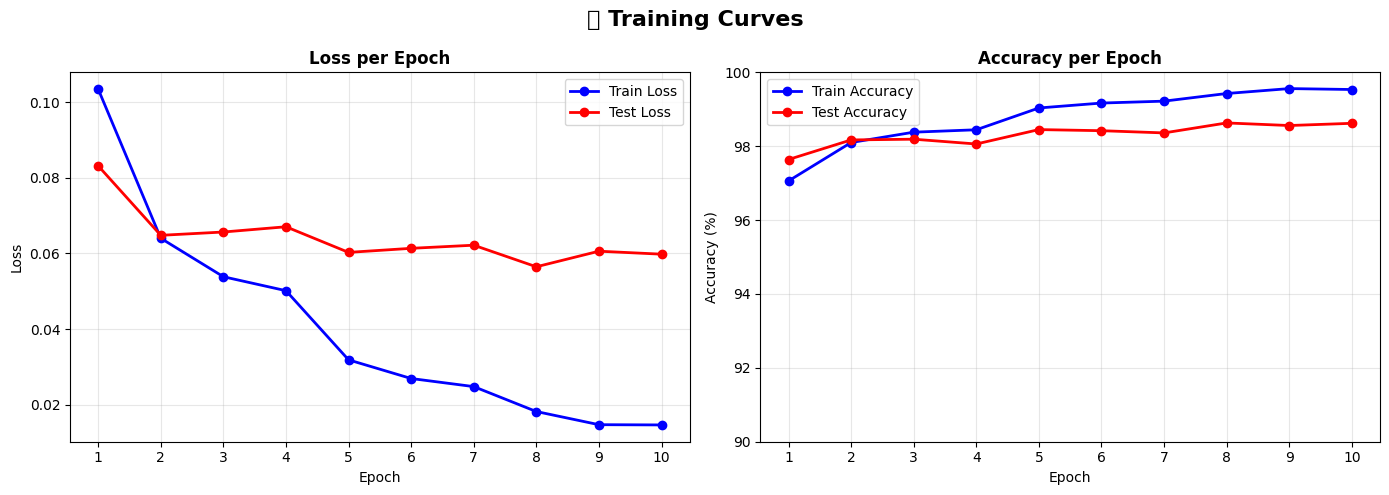

✅ Training curves saved!


In [10]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📈 Training Curves', fontsize=16, fontweight='bold')

# ─── Loss Plot ─────────────────────────────────────────────────────────────────
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax1.plot(epochs_range, history['test_loss'],  'r-o', label='Test Loss',  linewidth=2, markersize=6)
ax1.set_title('Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

# ─── Accuracy Plot ─────────────────────────────────────────────────────────────
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
ax2.plot(epochs_range, history['test_acc'],  'r-o', label='Test Accuracy',  linewidth=2, markersize=6)
ax2.set_title('Accuracy per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)
ax2.set_ylim([90, 100])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Training curves saved!')

## 🔍 Step 9: Detailed Evaluation — Confusion Matrix

A **Confusion Matrix** is a 10×10 grid where:
- **Rows** = actual digit labels
- **Columns** = predicted digit labels
- **Diagonal** = correct predictions ✅
- **Off-diagonal** = misclassifications ❌

It helps identify **which digits are most confused with each other** (e.g., 4 vs 9, or 3 vs 8).

C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\3497317753.py:46: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\3497317753.py:47: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
c:\Users\Sharmi\OneDrive\Documents\Machine Learning\pytorch-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128450 (\N{CARD INDEX DIVIDERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


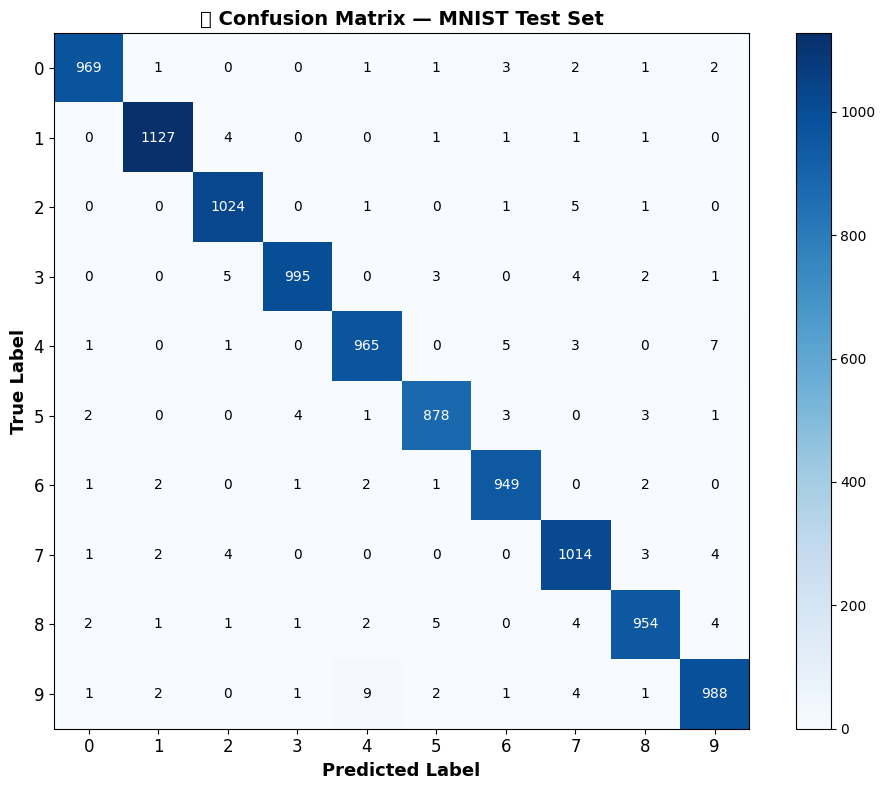


📊 Classification Report (Per-Digit Metrics):
              precision    recall  f1-score   support

     Digit 0       0.99      0.99      0.99       980
     Digit 1       0.99      0.99      0.99      1135
     Digit 2       0.99      0.99      0.99      1032
     Digit 3       0.99      0.99      0.99      1010
     Digit 4       0.98      0.98      0.98       982
     Digit 5       0.99      0.98      0.98       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       0.98      0.99      0.98      1028
     Digit 8       0.99      0.98      0.98       974
     Digit 9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [11]:
# ─── Load best model weights ───────────────────────────────────────────────────
model.load_state_dict(torch.load('best_digit_model.pth', map_location=device))
model.eval()

# ─── Collect all predictions ───────────────────────────────────────────────────
all_labels = []
all_preds  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

# ─── Build Confusion Matrix ────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10), fontsize=12)
ax.set_yticklabels(range(10), fontsize=12)

# Annotate each cell with count
thresh = cm.max() / 2.0
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=10,
                color='white' if cm[i, j] > thresh else 'black')

ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label',      fontsize=13, fontweight='bold')
ax.set_title('🗂️ Confusion Matrix — MNIST Test Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# ─── Per-Class Metrics ────────────────────────────────────────────────────────
print('\n📊 Classification Report (Per-Digit Metrics):')
print('='*55)
print(classification_report(all_labels, all_preds,
      target_names=[f'Digit {i}' for i in range(10)]))

## 🎯 Step 10: Visualize Predictions

Now let's see the model's predictions on individual test images.

- 🟢 **Green** title = correct prediction
- 🔴 **Red** title = wrong prediction (shows true vs predicted)

C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\3090451781.py:33: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\3090451781.py:34: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
c:\Users\Sharmi\OneDrive\Documents\Machine Learning\pytorch-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


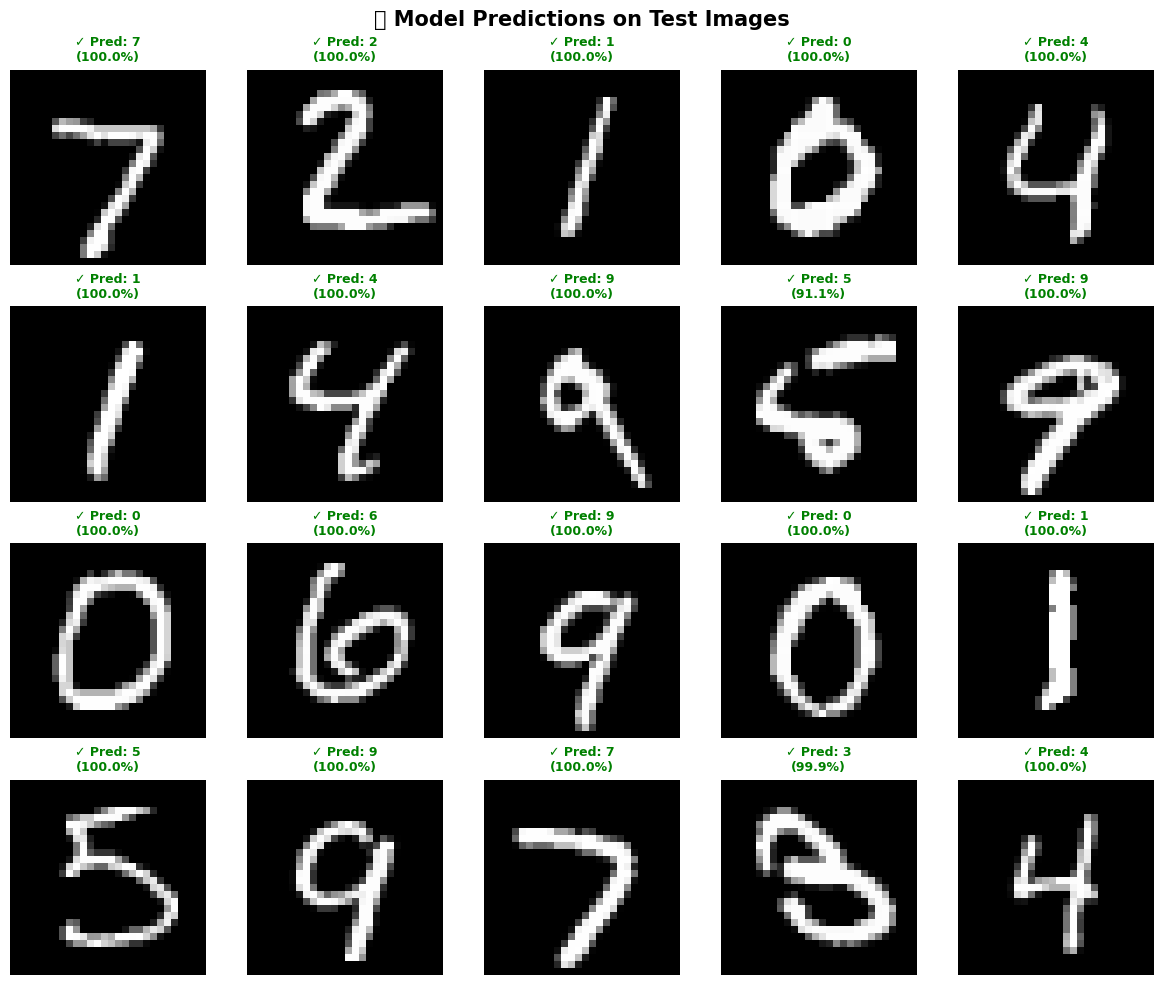

✅ Prediction visualization complete!


In [12]:
# Grab a batch of test images
test_images, test_labels = next(iter(test_loader))
test_images_dev = test_images.to(device)

model.eval()
with torch.no_grad():
    outputs     = model(test_images_dev)             # [B, 10] logits
    probs       = F.softmax(outputs, dim=1)          # Convert to probabilities
    confidences, predictions = torch.max(probs, 1)   # Top class + confidence

predictions = predictions.cpu().numpy()
confidences = confidences.cpu().numpy()

# ─── Plot 20 predictions ───────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle('🎯 Model Predictions on Test Images', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img   = test_images[i].squeeze().numpy()
    true  = test_labels[i].item()
    pred  = predictions[i]
    conf  = confidences[i] * 100
    
    ax.imshow(img, cmap='gray')
    
    if pred == true:
        ax.set_title(f'✓ Pred: {pred}\n({conf:.1f}%)', color='green', fontsize=9, fontweight='bold')
    else:
        ax.set_title(f'✗ True: {true} | Pred: {pred}\n({conf:.1f}%)', color='red', fontsize=8, fontweight='bold')
    
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Prediction visualization complete!')

## 🔬 Step 11: Analyze Misclassified Images

It's very informative to look at the images the model **got wrong**. These are often:
- Unusual or ambiguous handwriting
- Digits that look visually similar (e.g., 1 vs 7, 4 vs 9)

❌ Total misclassified: 137 / 10000 (1.37%)


C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\2315738020.py:46: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sharmi\AppData\Local\Temp\ipykernel_13356\2315738020.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('misclassified.png', dpi=120, bbox_inches='tight')
c:\Users\Sharmi\OneDrive\Documents\Machine Learning\pytorch-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


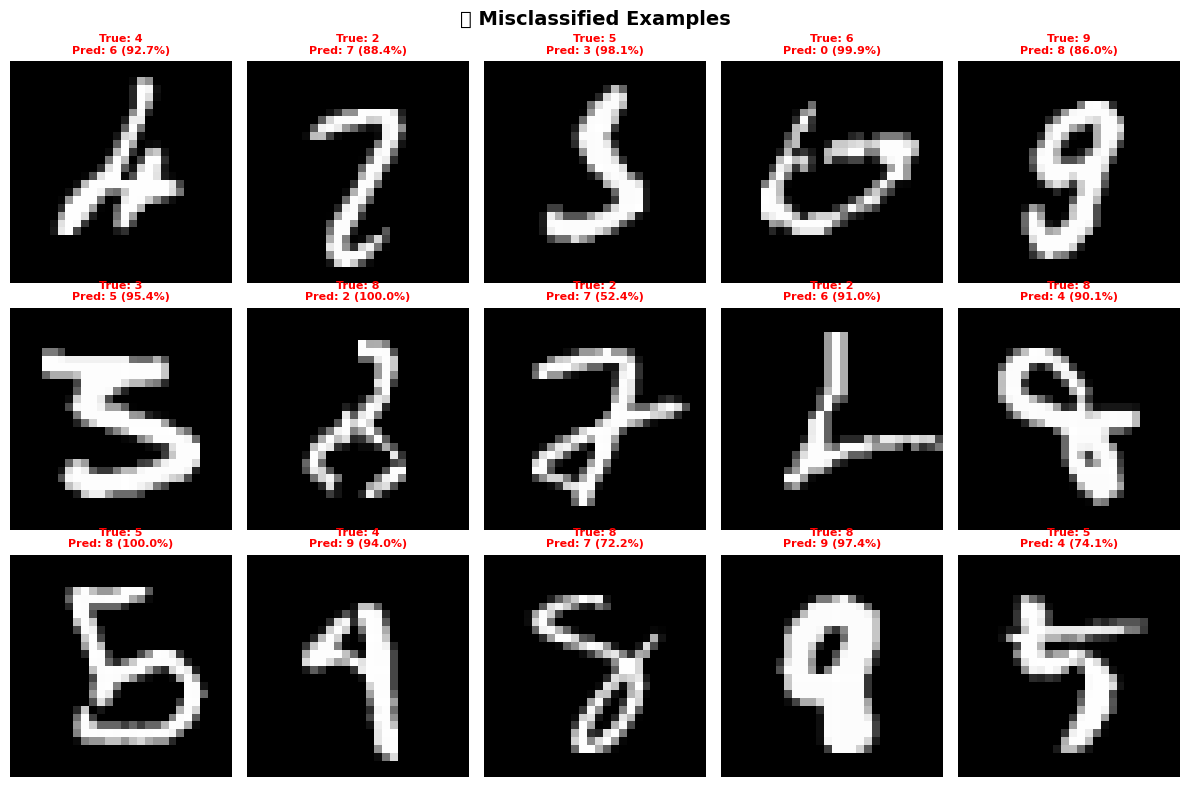

In [13]:
# Find misclassified examples from the full test set
all_test_images = []
all_test_labels = []
all_test_preds  = []
all_test_confs  = []

model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        out  = model(imgs.to(device))
        prob = F.softmax(out, dim=1)
        conf, pred = torch.max(prob, 1)
        all_test_images.append(imgs.cpu())
        all_test_labels.append(lbls)
        all_test_preds.append(pred.cpu())
        all_test_confs.append(conf.cpu())

all_test_images = torch.cat(all_test_images)
all_test_labels = torch.cat(all_test_labels)
all_test_preds  = torch.cat(all_test_preds)
all_test_confs  = torch.cat(all_test_confs)

# Find misclassified indices
wrong_mask   = (all_test_preds != all_test_labels)
wrong_images = all_test_images[wrong_mask]
wrong_labels = all_test_labels[wrong_mask]
wrong_preds  = all_test_preds[wrong_mask]
wrong_confs  = all_test_confs[wrong_mask]

total_wrong  = wrong_mask.sum().item()
print(f'❌ Total misclassified: {total_wrong} / {len(all_test_labels)} ({total_wrong/len(all_test_labels)*100:.2f}%)')

# Plot first 15 misclassified
n_show = min(15, total_wrong)
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
fig.suptitle('❌ Misclassified Examples', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off'); continue
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {wrong_labels[i].item()}\nPred: {wrong_preds[i].item()} ({wrong_confs[i]*100:.1f}%)',
                 fontsize=8, color='red', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('misclassified.png', dpi=120, bbox_inches='tight')
plt.show()

## 💾 Step 12: Save and Load the Model

PyTorch provides two ways to save a model:

| Method | What's saved | Use case |
|---|---|---|
| `torch.save(model.state_dict(), path)` | Only weights (recommended) | Flexible, portable |
| `torch.save(model, path)` | Entire model object | Quick but less portable |

In [14]:
# ─── Save the final model ─────────────────────────────────────────────────────
torch.save(model.state_dict(), 'digit_recognizer_final.pth')
print('✅ Model saved as digit_recognizer_final.pth')

# ─── Load model (example of how to reload) ────────────────────────────────────
loaded_model = DigitRecognizer(dropout_rate=0.2)                      # Must define same architecture
loaded_model.load_state_dict(torch.load('best_digit_model.pth',
                                        map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print('✅ Best model loaded successfully!')

# Quick sanity check
sample_img, sample_label = test_dataset[42]
sample_img = sample_img.unsqueeze(0).to(device)   # Add batch dimension: [28,28] → [1,1,28,28]

with torch.no_grad():
    out  = loaded_model(sample_img)
    prob = F.softmax(out, dim=1)
    conf, pred = torch.max(prob, 1)

print(f'\n🔎 Sanity Check (test image #42):')
print(f'   True label : {sample_label}')
print(f'   Prediction : {pred.item()} (confidence: {conf.item()*100:.2f}%)')

✅ Model saved as digit_recognizer_final.pth
✅ Best model loaded successfully!

🔎 Sanity Check (test image #42):
   True label : 4
   Prediction : 4 (confidence: 100.00%)


## 📋 Step 13: Final Summary

Let's print a comprehensive summary of everything we've done.

In [15]:
final_train_loss, final_train_acc = evaluate(model, train_loader, criterion, device)
final_test_loss,  final_test_acc  = evaluate(model, test_loader,  criterion, device)

print('=' * 55)
print('         🏁 FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Architecture     : 3-Layer MLP (784→512→256→128→10)')
print(f'  Total Parameters : {total_params:,}')
print(f'  Epochs Trained   : {EPOCHS}')
print(f'  Batch Size       : {BATCH_SIZE}')
print(f'  Optimizer        : Adam (lr={LEARNING_RATE}, wd=1e-4)')
print(f'  Regularization   : Dropout (0.2) + Weight Decay')
print('─' * 55)
print(f'  Train Loss       : {final_train_loss:.4f}')
print(f'  Train Accuracy   : {final_train_acc:.2f}%')
print(f'  Test Loss        : {final_test_loss:.4f}')
print(f'  Test Accuracy    : {final_test_acc:.2f}%')
print(f'  Best Accuracy    : {best_accuracy:.2f}%')
print('=' * 55)

# Error analysis
errors = int((1 - final_test_acc/100) * len(test_dataset))
print(f'\n  Correctly classified : {len(test_dataset) - errors:,} / {len(test_dataset):,}')
print(f'  Misclassified        : {errors:,} / {len(test_dataset):,}')

         🏁 FINAL MODEL SUMMARY
  Architecture     : 3-Layer MLP (784→512→256→128→10)
  Total Parameters : 567,434
  Epochs Trained   : 10
  Batch Size       : 64
  Optimizer        : Adam (lr=0.001, wd=1e-4)
  Regularization   : Dropout (0.2) + Weight Decay
───────────────────────────────────────────────────────
  Train Loss       : 0.0049
  Train Accuracy   : 99.86%
  Test Loss        : 0.0565
  Test Accuracy    : 98.63%
  Best Accuracy    : 98.63%

  Correctly classified : 9,863 / 10,000
  Misclassified        : 137 / 10,000


---

## 🎓 Concepts Recap

| Concept | What we used | Why |
|---|---|---|
| **Dataset** | MNIST (60K train, 10K test) | Standard benchmark for digit recognition |
| **Normalization** | Mean=0.1307, Std=0.3081 | Stabilizes gradient descent |
| **Architecture** | 3-hidden-layer MLP | Balance between capacity and efficiency |
| **Activation** | ReLU | Non-linearity, avoids vanishing gradient |
| **Regularization** | Dropout (0.2) + L2 weight decay | Prevents overfitting |
| **Loss Function** | CrossEntropyLoss | Standard for multi-class classification |
| **Optimizer** | Adam | Adaptive, fast convergence |
| **LR Scheduler** | StepLR (gamma=0.5) | Fine-tune learning late in training |
| **Evaluation** | Confusion Matrix + Classification Report | Understand per-class performance |
